# Pseudotime comparison

Build a reordered CSV first, for example:

```bash
python reorder_rna.py --method slingshot
```

Cells are matched by gene expression. **Moved** means experimental capture time `h` does not equal the time slot `h_pseudo` implied by pseudotime rank (see helper code).

This notebook only plots the **heatmap** (rows = $\mathrm{Time}$, columns = $\tau$) and reports the **percent of cells moved**.


## 1. Configuration

Set **`METHOD`**, then run the cells below in order. Re-run **Load reordering** after you change `METHOD`.


In [15]:
from pathlib import Path

METHOD = "phate"  # "dpt" | "slingshot" | "phate"

ROOT = Path.cwd()
DATA = ROOT / "data" / "rna"
_allowed = {"dpt", "slingshot", "phate"}
assert METHOD in _allowed, f"METHOD must be one of {_allowed}"

PATH_ORIG = DATA / "rna.csv"
PATH_BY_METHOD = {
    "dpt": DATA / "rna_reordered_dpt.csv",
    "slingshot": DATA / "rna_reordered_slingshot.csv",
    "phate": DATA / "rna_reordered_phate.csv",
}

print("METHOD =", METHOD)


METHOD = phate


## 2. Imports


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


## 3. Helpers


In [17]:
def load_rna(path: Path):
    df = pd.read_csv(path)
    genes = [c for c in df.columns if c != "h"]
    return df, genes


def normalize_for_merge(df: pd.DataFrame, genes: list) -> pd.DataFrame:
    out = df.copy()
    for g in genes:
        out[g] = out[g].astype(np.float64).round(8)
    out["h"] = out["h"].astype(np.float64)
    return out


def build_positions(df_orig: pd.DataFrame, genes: list, path: Path, name: str):
    if not path.is_file():
        raise FileNotFoundError(f"Missing {path} — run: python reorder_rna.py --method {name}")
    df_r, _ = load_rna(path)
    df_r = normalize_for_merge(df_r, genes)
    df_r["pseudo_rank"] = np.arange(len(df_r), dtype=int)
    m = df_orig[["cell_id", "orig_rank", "h"] + genes].merge(
        df_r[["pseudo_rank", "h"] + genes],
        on=genes,
        how="inner",
        suffixes=("_orig", "_reord"),
        validate="one_to_one",
    )
    if len(m) != len(df_orig):
        raise ValueError(
            f"{name}: merge matched {len(m)}/{len(df_orig)} rows — check CSVs / duplicates"
        )
    m["delta_rank"] = m["pseudo_rank"] - m["orig_rank"]
    m["h"] = m["h_orig"]
    n = len(m)
    hs = sorted(pd.unique(m["h"].astype(float)))
    K = len(hs)
    if K == 0:
        m["h_pseudo"] = np.nan
        m["h_changed"] = False
    else:
        seg = np.minimum((m["pseudo_rank"].astype(int) * K // n).astype(int), K - 1)
        m["h_pseudo"] = [hs[i] for i in seg]
        m["h_changed"] = ~np.isclose(
            m["h"].astype(np.float64),
            np.asarray(m["h_pseudo"], dtype=np.float64),
            rtol=0,
            atol=1e-5,
        )
    return m[
        [
            "cell_id",
            "orig_rank",
            "h",
            "h_pseudo",
            "h_reord",
            "pseudo_rank",
            "delta_rank",
            "h_changed",
        ]
    ]


def _assign_h_from_pseudotime(t: pd.DataFrame):
    """Split pseudotime rank into K = #unique h segments; label each segment with ordered timepoints."""
    t = t.dropna(subset=["h", "pseudo_rank"]).copy()
    n = len(t)
    if n == 0:
        return t, [], 0
    hs = sorted(pd.unique(t["h"].astype(float)))
    K = len(hs)
    if K == 0:
        return t, [], 0
    seg = np.minimum((t["pseudo_rank"].astype(int) * K // n).astype(int), K - 1)
    t["seg"] = seg
    t["h_pseudo"] = [hs[i] for i in seg]
    return t, hs, K


def flow_matrix(t: pd.DataFrame) -> pd.DataFrame:
    """Rows = experimental h; cols = h implied by pseudotime segment."""
    t2, hs, K = _assign_h_from_pseudotime(t)
    n = len(t2)
    if n == 0 or K == 0:
        return pd.DataFrame(dtype=np.int64)
    ct = pd.crosstab(t2["h"], t2["h_pseudo"])
    ct = ct.reindex(index=hs, columns=hs, fill_value=0)
    return ct.fillna(0).astype(np.int64)


## 4. Load `rna.csv` (once per session)


In [18]:
df_orig, genes = load_rna(PATH_ORIG)
df_orig = normalize_for_merge(df_orig, genes)
df_orig["orig_rank"] = np.arange(len(df_orig), dtype=int)
df_orig["cell_id"] = [f"Cell_{i}" for i in range(len(df_orig))]
print(len(df_orig), "cells,", len(genes), "genes")


960 cells, 45 genes


## 5. Load reordering for `METHOD`


In [19]:
t = build_positions(df_orig, genes, PATH_BY_METHOD[METHOD], METHOD)
print(f"Loaded {METHOD}: {len(t)} cells")


Loaded phate: 960 cells


## 6. Heatmap


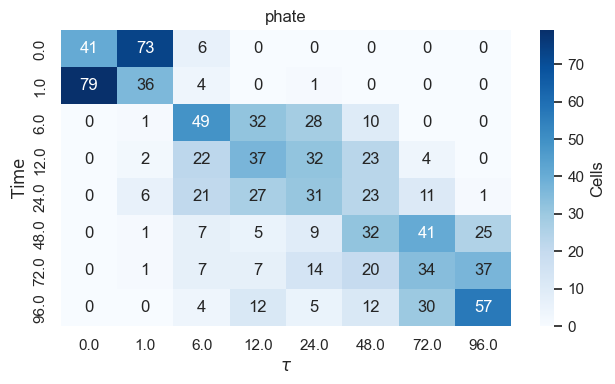

In [20]:
F = flow_matrix(t)
if F.empty:
    print("No heatmap data.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    sns.heatmap(F, annot=True, fmt="d", cmap="Blues", ax=ax, cbar_kws={"label": "Cells"})
    ax.set_title(METHOD)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\mathrm{Time}$")
    plt.tight_layout()
    plt.show()


## 7. Percent moved


In [21]:
n = len(t)
if n == 0:
    print("No cells loaded.")
else:
    moved = int(t["h_changed"].sum())
    pct = 100.0 * float(t["h_changed"].mean())
    print(
        f"Percent moved (experimental time ≠ pseudotime slot): {pct:.2f}%  ({moved} / {n} cells)"
    )


Percent moved (experimental time ≠ pseudotime slot): 66.98%  (643 / 960 cells)
